In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.interpolate import interpn

import herculens
from herculens import PSF, Noise, PixelGrid
from herculens import MPMassModel, MPLensImage
from Herculens_overrides import (
    LightModelRTU,
    PixelatedLightRTU,
    LensImageRTUGrid,
    LensImageRTUGridLowMem,
    SimpleFFTConvolve
)
from Hercules_MP_overrides import (
    MPLightModelRTU,
    MPLensImageRTUGrid,
    MPLensImageRTUGridLowMem
)
import jax_lensing_profiles

In [3]:
def half_colormap(cmap_name='viridis', half='upper', n=256):
    cmap = plt.get_cmap(cmap_name)
    if half == 'lower':
        c = cmap(np.linspace(0.0, 0.5, n))
    elif half == 'upper':
        c = cmap(np.linspace(0.5, 1.0, n))
    else:
        raise ValueError("half must be 'lower' or 'upper'")
    new_cmap = colors.LinearSegmentedColormap.from_list(
        f"{cmap_name}_{half}_half", c
    )
    return new_cmap


new_cmap =half_colormap("PuOr_r")

In [4]:
ny, nx = 250, 250
pix_scale = 0.025
half_size_x = nx * pix_scale / 2
half_size_y = ny * pix_scale / 2

# position of the (0, 0) with respect to bottom left pixel
ra_at_xy_0 = -half_size_x + pix_scale / 2
dec_at_xy_0 = -half_size_y + pix_scale / 2

# transformation matrix pixel <-> angle
transform_pix2angle = pix_scale * np.eye(2)  
kwargs_pixel = {
    'nx': nx,
    'ny': ny,
    'ra_at_xy_0': ra_at_xy_0,
    'dec_at_xy_0': dec_at_xy_0,
    'transform_pix2angle': transform_pix2angle
}

pixel_grid = PixelGrid(**kwargs_pixel)
xgrid, ygrid = pixel_grid.pixel_coordinates
x_axis = xgrid[0]
y_axis = ygrid[:, 0]
extent = pixel_grid.extent

print(f"image size : ({nx}, {ny}) pixels")
print(f"pixel size : {pix_scale} arcsec")
print(f"x range    : {xgrid[0, 0], xgrid[0, -1]} arcsec")
print(f"y range    : {ygrid[0, 0], ygrid[-1, 0]} arcsec")

image size : (250, 250) pixels
pixel size : 0.025 arcsec
x range    : (np.float64(-3.1125), np.float64(3.1125000000000007)) arcsec
y range    : (np.float64(-3.1125), np.float64(3.1125000000000007)) arcsec


In [5]:
# FWHM to sigma
sigma2 = 1 / (2 * jnp.log(2))

# a 15x15 kernel
psf_coords = jnp.linspace(-7, 7, 15)
psf_xx, psf_yy = jnp.meshgrid(psf_coords, psf_coords)
psf_rr2 = psf_xx**2 + psf_yy**2

psf_kernel = jnp.exp(-0.5 * psf_rr2/sigma2)
psf_kernel /= psf_kernel.sum()

In [6]:
psf_holder = PSF(psf_type='NONE')

exp_time = 2000
sigma_bkd = 0.005
kwargs_noise = {'background_rms': sigma_bkd, 'exposure_time': exp_time}
noise = Noise(nx, ny, **kwargs_noise)

In [58]:
mass_model = MPMassModel([
    ['SIS'],
    ['SIS']
])
pixel_grid_shape = 64

source_input_rtu = LightModelRTU([
    PixelatedLightRTU(
        interpolation_type='fast_bilinear',
        derivative_type='autodiff',
        # adaptive_grid=True,
        rtu_grid=True,
        allow_extrapolation=False
    )
], kwargs_pixelated={'num_pixels': pixel_grid_shape})

light_model_rtu = MPLightModelRTU([None, None, source_input_rtu])

psf_rtu = SimpleFFTConvolve(psf_kernel, (ny, nx))

kwargs_numerics = {'supersampling_factor': 4}

lens_image_rtu = MPLensImageRTUGrid(
    pixel_grid, psf_holder, noise,
    mass_model, light_model_rtu,
    kwargs_numerics=kwargs_numerics
)

In [24]:
source_coords = jnp.linspace(-1, 1, pixel_grid_shape) * pix_scale
source_xx, source_yy = jnp.meshgrid(source_coords, source_coords)
source_rr2 = source_xx**2 + source_yy**2

source = 5 * jnp.exp(-0.5 * source_rr2/0.005**2)

kwargs_source_uniform = [{'pixels': source}]

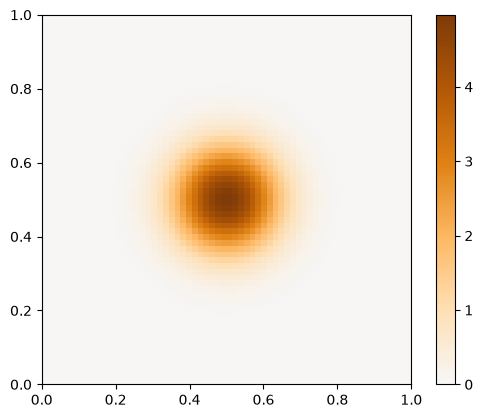

In [46]:
plt.imshow(source, extent=[0, 1, 0, 1], cmap=new_cmap, vmin=0)
plt.colorbar();

In [69]:
kwargs_mass = [
    [{'theta_E': 1.0, 'center_x': 0.0, 'center_y': 0.0}],
    [{'theta_E': 0.9, 'center_x': 0.9, 'center_y': 0.0}]
]

kwargs_light_rtu = [
    [],
    [],
    kwargs_source_uniform
]

eta_flat=jnp.array([1.05])

In [70]:
image_rtu, (source_centers, source_edges) = lens_image_rtu.model(
    eta_flat=eta_flat,
    kwargs_mass=kwargs_mass,
    kwargs_light=kwargs_light_rtu,
    return_pixels_coords=True
)

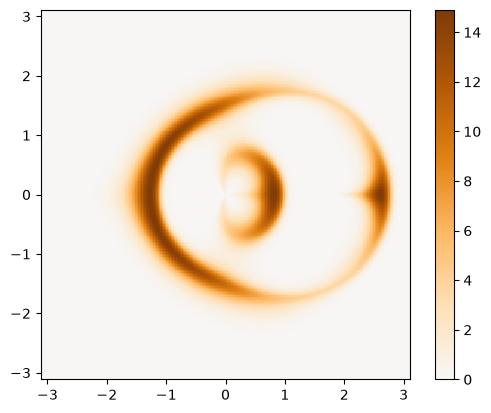

In [71]:
plt.imshow(image_rtu, extent=pixel_grid.extent, cmap=new_cmap, vmin=0)
plt.colorbar();

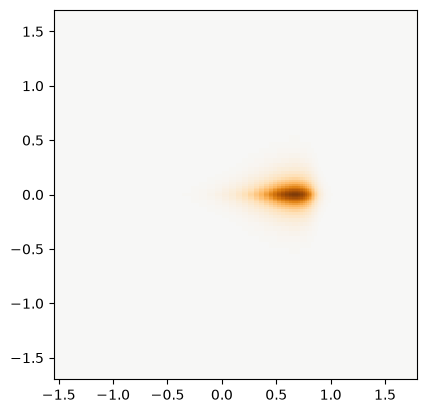

In [62]:
plt.pcolormesh(
    source_edges[-1][1][:, 0],
    source_edges[-1][1][:, 1],
    source,
    # shading = 'flat' requires the pixel *edges*, other shadings require the pixel *centers*, see matplotlib's documentation for details
    shading='flat',
    cmap=new_cmap,
    vmin=0
)
plt.gca().set_aspect(1)

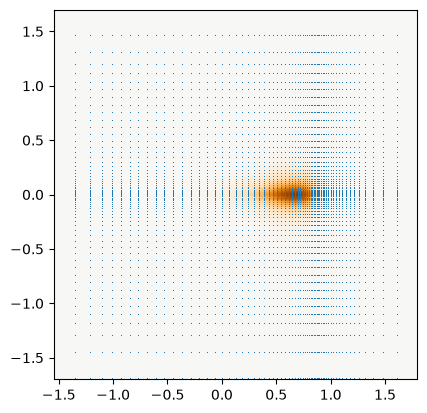

In [63]:
plt.pcolormesh(
    source_edges[-1][1][:, 0],
    source_edges[-1][1][:, 1],
    source,
    # shading = 'flat' requires the pixel *edges*, other shadings require the pixel *centers*, see matplotlib's documentation for details
    shading='flat',
    cmap=new_cmap,
    vmin=0
)

a, b = np.meshgrid(*source_edges[-1][1].T)
plt.plot(a.flatten(), b.flatten(), ',')
plt.gca().set_aspect(1);

In [64]:
centers_min = source_centers[-1][1][0]
centers_max = source_centers[-1][1][-1]

xi = np.meshgrid(
    jnp.linspace(centers_min[0], centers_max[0], pixel_grid_shape),
    jnp.linspace(centers_min[1], centers_max[1], pixel_grid_shape),
)
source_real_space = interpn(
    np.array(source_centers[-1][1].T),
    np.array(source),
    np.moveaxis(np.array(xi), 0, 2),
    bounds_error=False,
    fill_value=0.0,
    method='linear'
)

kwargs_source_real = [{'pixels': source_real_space}]

In [ ]:
source_input = LightModelRTU([
    PixelatedLightRTU(
        interpolation_type='fast_bilinear',
        derivative_type='autodiff',
        adaptive_grid=True,
        allow_extrapolation=False
    )
], kwargs_pixelated={'num_pixels': pixel_grid_shape})

light_model = MPLightModelRTU([None, None, source_input])

psf_rtu = SimpleFFTConvolve(psf_kernel, (ny, nx))

lens_image = MPLensImageRTUGrid(
    pixel_grid, psf_holder, noise,
    mass_model, light_model,
    kwargs_numerics=kwargs_numerics
)

In [67]:
kwargs_light = [
    [],
    [],
    kwargs_source_real
]

In [68]:
image = lens_image_rtu.model(
    eta_flat=eta_flat,
    kwargs_mass=kwargs_mass,
    kwargs_light=kwargs_light,
    return_pixels_coords=False
)

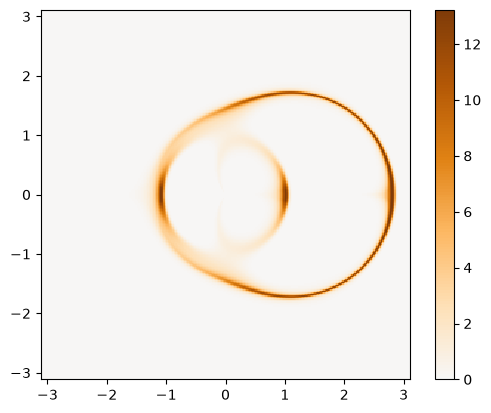

In [72]:
plt.imshow(image, extent=pixel_grid.extent, cmap=new_cmap, vmin=0)
plt.colorbar();

In [ ]:
# lack of arc mask it making this look different I think